In [129]:
#ライブラリをimport
import os
from datetime import datetime
from glob import glob

from dotenv import load_dotenv
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine

In [130]:
#データベースへのパスを作成
load_dotenv()
data_base = os.getenv("DATABASE_URL")
engine = create_engine(f"{data_base}")

In [131]:
#データベースから人気動画のデータをロード
df = pd.read_sql_query(
    '''
    SELECT *
    FROM popular_videos
    ''',engine)
#重複を省いた動画数とチャンネル数を確認
print(f"集計時間は{len(df["daytime"].unique())}時間です。")
print(f"データ数は{len(df["title"])}個です。")
print(f"動画数は{len(df["title"].unique())}個です。")
print(f"チャンネル数は{len(df["channel_id"].unique())}個です。")

集計時間は81時間です。
データ数は4050個です。
動画数は293個です。
チャンネル数は215個です。


In [132]:
#総データに占める各カテゴリの動画数を確認
video_count_by_category = pd.read_sql_query(
    '''
    SELECT category_title, COUNT(*) AS category_count
    FROM popular_videos
    GROUP BY category_title
    ORDER BY category_count
    ''',engine)
plt.figure(figsize=(10,5))
sns.barplot(video_count_by_category, x="category_title", y="category_count")
plt.title("Video count by category")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.savefig("../outputs/figures/video_count_by_category.png", format="png")
plt.close()

GamingとMusicのカテゴリの動画が非常にランキングに多いことを確認。

上記２つにEntertainmentを加えた3カテゴリがランキングに上がった動画のほとんどを構成しています。

時系列による変動を見るため、時系列による人気カテゴリの推移を確認します。

In [134]:
#時系列によるcategoryの推移を確認
popular_category_transition = pd.read_sql_query(
    '''
    SELECT daytime, category_title, COUNT(category_title) AS category_count
    FROM popular_videos
    GROUP BY daytime, category_title
    ORDER BY daytime
    ''',engine)
plt.figure(figsize=(10,5))
sns.lineplot(data=popular_category_transition, x="daytime", y="category_count", hue="category_title")
plt.title("Popular_category_transition")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.savefig("../outputs/figures/popular_category_transition.png", format="png")
plt.close()

タイミングによってGamingとMusicの入れ替わりがありますが、どのタイミングでもこの２カテゴリの人気が非常に高く、次点でEntertainmentが人気であることが確認できました。

特定の動画やチャンネルが人気なのかを確認するために、動画単位、チャンネル単位のカテゴリ別ランキング滞在時間を確認します。

In [138]:
#カテゴリ別の動画のランキング滞在時間を確認
video_dwell_time = pd.read_sql_query(
    '''
    SELECT video_id, category_title,COUNT(title) AS title_count
    FROM popular_videos
    GROUP BY video_id, category_title
    ORDER BY title_count DESC
    ''',engine)
plt.figure(figsize=(10,5))
sns.histplot(video_dwell_time, x="title_count", hue="category_title", multiple="stack", bins=25)
plt.title("Video dwell time on ranking")
plt.xlabel("dwell time(hour)")
plt.ylabel("video count")
plt.xticks(range(0,80,5))
plt.grid(axis="y", linewidth=0.3)
plt.savefig("../outputs/figures/video_dwell_time_on_ranking.png", format="png")
plt.close()

In [137]:
#カテゴリ別のチャンネルのランキング滞在時間を確認
channel_dwell_time = pd.read_sql_query(
    '''
    SELECT channel_id, category_title, COUNT(channel_id) AS channel_count
    FROM popular_videos
    GROUP BY channel_id, category_title
    ORDER BY channel_count DESC
    ''',engine)
plt.figure(figsize=(10,5))
sns.histplot(channel_dwell_time, x="channel_count", hue="category_title", multiple="stack", bins=30)
plt.title("Channel dwell time on ranking")
plt.xlabel("dwell time(hour)")
plt.ylabel("channel count")
plt.xticks(range(0,80,5))
plt.yticks(range(0,20,2))
plt.grid(axis="y", linewidth=0.3)
plt.savefig("../outputs/figures/channel_dwell_time_on_ranking.png", format="png")
plt.close()

動画単位のランキング滞在時間を見ると、ランキング滞在N時間以上の長時間人気な動画はほとんどMusicカテゴリであり、Musicカテゴリでは特定の動画が特に人気であることが分かりました。

一方、チャンネル単位でランキング滞在時間を見ると、Gaming, Musicともに長時間ランキングに滞在している人気チャンネルが存在することが確認できました。

このことから、Gamingカテゴリの人気チャンネルでは１動画の人気はMusicカテゴリほど伸びず、チャンネルの人気が伸びる可能性が示唆されます。

確認のため、Gamingカテゴリで人気の3動画とMusicカテゴリで人気の3動画の動画再生回数の推移を確認します。

その後、Gamingカテゴリの人気チャンネルとMusicカテゴリの人気チャンネルのチャンネル登録者数の推移を確認します。

In [139]:
top_music_videos_transition = pd.read_sql_query(
    '''
    WITH  music_top AS(
    SELECT video_id,category_title,COUNT(title) AS title_count
    FROM popular_videos
    WHERE category_title='{Music}'
    GROUP BY video_id, category_title
    ORDER BY title_count DESC
    LIMIT 3)
    SELECT v.daytime, v.video_id, CAST(v.view_count AS INTEGER),m.category_title
    FROM video_statistics v
    INNER JOIN music_top m ON m.video_id = v.video_id
    ORDER BY v.daytime
    ''',engine)
top_gaming_videos_transition = pd.read_sql_query(
    '''
    WITH  gaming_top AS(
    SELECT video_id,category_title,COUNT(title) AS title_count
    FROM popular_videos
    WHERE category_title='{Gaming}'
    GROUP BY video_id, category_title
    ORDER BY title_count DESC
    LIMIT 3)
    SELECT v.daytime, v.video_id, CAST(v.view_count AS INTEGER),g.category_title
    FROM video_statistics v
    INNER JOIN gaming_top g ON g.video_id = v.video_id
    ORDER BY v.daytime
    ''',engine)
top_videos_transition=pd.concat([top_gaming_videos_transition, top_music_videos_transition], ignore_index=True)
plt.figure(figsize=(10,5))
sns.lineplot(data=top_videos_transition, x="daytime", y="view_count", hue="category_title", style="video_id")
plt.title("Top3_videos_view_count_transition")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.savefig("../outputs/figures/top3_videos_view_count_transition.png", format="png")
plt.close()

Musicカテゴリの動画の方がGamingカテゴリのものと比較して明らかに動画再生数の伸びが良いことを確認。

続いてチャンネル登録者数の推移を確認します。

In [140]:
top_music_channels_subscriber = pd.read_sql_query(
    '''
    WITH top_channels AS(
    SELECT channel_id, category_title, COUNT(channel_id) AS channel_count
    FROM popular_videos
    WHERE category_title='{Music}'
    GROUP BY channel_id, category_title
    ORDER BY channel_count DESC
    LIMIT 3)
    SELECT p.daytime, p.channel_id, CAST(p.subscriber_count AS INTEGER), t.category_title
    FROM popular_channels p
    INNER JOIN top_channels t ON p.channel_id=t.channel_id
    ORDER BY p.daytime
    ''',engine)
top_gaming_channels_subscriber = pd.read_sql_query(
    '''
    WITH top_channels AS(
    SELECT channel_id, category_title, COUNT(channel_id) AS channel_count
    FROM popular_videos
    WHERE category_title='{Gaming}'
    GROUP BY channel_id, category_title
    ORDER BY channel_count DESC
    LIMIT 3)
    SELECT p.daytime, p.channel_id, CAST(p.subscriber_count AS INTEGER), t.category_title
    FROM popular_channels p
    INNER JOIN top_channels t ON p.channel_id=t.channel_id
    ORDER BY p.daytime
    ''',engine)
top_channels_subscriber = pd.concat([top_music_channels_subscriber,top_gaming_channels_subscriber], ignore_index=True)
top_channels_subscriber["first_subscriber_count"]= top_channels_subscriber.groupby("channel_id")["subscriber_count"].transform("first")
top_channels_subscriber["changes_in_subscriber"] = top_channels_subscriber["subscriber_count"]-top_channels_subscriber["first_subscriber_count"]
plt.figure(figsize=(10,5))
sns.lineplot(data=top_channels_subscriber, x="daytime", y="changes_in_subscriber", hue="category_title", style="channel_id")
plt.title("Top3_channels_subscriber_count_transition")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.savefig("../outputs/figures/top3_channels_subscriber_count_transition.png", format="png")
plt.close()

In [141]:
top_channels_subscriber

,daytime,channel_id,subscriber_count,category_title,first_subscriber_count,changes_in_subscriber
0,2025-11-24 12:00:09,UCaO6TYtlC8U5ttz62hTrZgg,31500000,{Music},31500000,0
1,2025-11-24 13:47:18,UCaO6TYtlC8U5ttz62hTrZgg,31500000,{Music},31500000,0
2,2025-11-24 14:42:47,UCaO6TYtlC8U5ttz62hTrZgg,31500000,{Music},31500000,0
3,2025-11-24 15:57:00,UCaO6TYtlC8U5ttz62hTrZgg,31500000,{Music},31500000,0
4,2025-11-24 16:35:26,UCaO6TYtlC8U5ttz62hTrZgg,31500000,{Music},31500000,0
...,...,...,...,...,...,...
457,2025-11-28 07:19:06,UCZMRuagdTBKmmrFtSMN48Xw,1800000,{Gaming},1800000,0
458,2025-11-28 07:19:06,UCj4PjeVMnNTHIR5EeoNKPAw,2570000,{Gaming},2560000,10000
459,2025-11-28 08:18:20,UCZMRuagdTBKmmrFtSMN48Xw,1800000,{Gaming},1800000,0
460,2025-11-28 08:18:20,UCj4PjeVMnNTHIR5EeoNKPAw,2570000,{Gaming},2560000,10000


チャンネル登録者数は有効数字３桁であるため、もともと登録者数が多いチャンネルの登録者数の増減は切り捨てになっており、調査できませんでした。

唯一調査できたMusicカテゴリのチャンネルの増加数は2000人でした。

次に、最もチャンネルのランキング掲載期間が短い場合でも掲載された動画の再生数やチャンネル登録者数の増加に反映されるのかを調査します。

ランキング滞在時間ワーストのチャンネルの動画の再生数の推移とそのチャンネルの登録者数の推移を確認します。

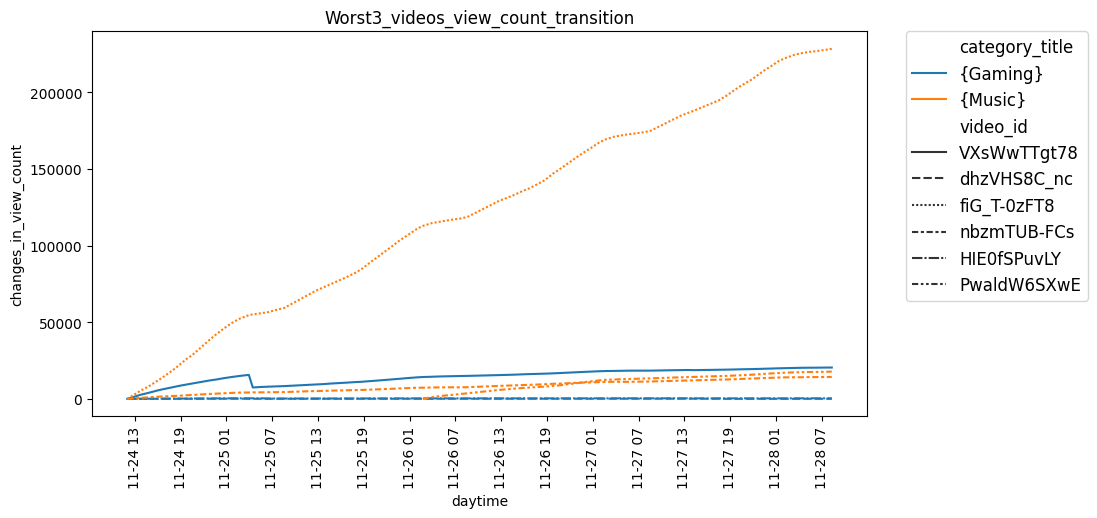

In [147]:
worst_videos_transition = pd.read_sql_query(
    '''
    WITH worst_channels AS(
    SELECT channel_id,category_title,COUNT(channel_id) AS channel_count
    FROM popular_videos
    WHERE category_title IN ('{Music}', '{Gaming}')
    GROUP BY channel_id, category_title
    HAVING COUNT(channel_id)=1),
    worst_music_channels AS(
    SELECT p.daytime, p.video_id, w.channel_id, w.category_title, w.channel_count
    FROM popular_videos p
    INNER JOIN worst_channels w ON p.channel_id=w.channel_id
    WHERE w.category_title='{Music}'
    ORDER BY p.daytime
    LIMIT 3),
    worst_gaming_channels AS(
    SELECT p.daytime, p.video_id, w.channel_id, w.category_title, w.channel_count
    FROM popular_videos p
    INNER JOIN worst_channels w ON p.channel_id=w.channel_id
    WHERE w.category_title='{Gaming}'
    ORDER BY p.daytime
    LIMIT 3),
    selected_channels AS(
    SELECT * FROM worst_music_channels
    UNION ALL
    SELECT * FROM worst_gaming_channels)
    SELECT vs.daytime, vs.video_id, CAST(vs.view_count AS INTEGER), sc.category_title
    FROM  video_statistics vs
    INNER JOIN selected_channels sc ON vs.video_id = sc.video_id
    ORDER BY vs.daytime
    ''',engine)
worst_videos_transition["first_view_count"]= worst_videos_transition.groupby("video_id")["view_count"].transform("first")
worst_videos_transition["changes_in_view_count"] = worst_videos_transition["view_count"]-worst_videos_transition["first_view_count"]
plt.figure(figsize=(10,5))
sns.lineplot(data=worst_videos_transition, x="daytime", y="changes_in_view_count", hue="category_title", style="video_id")
plt.title("Worst3_videos_view_count_transition")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.show()

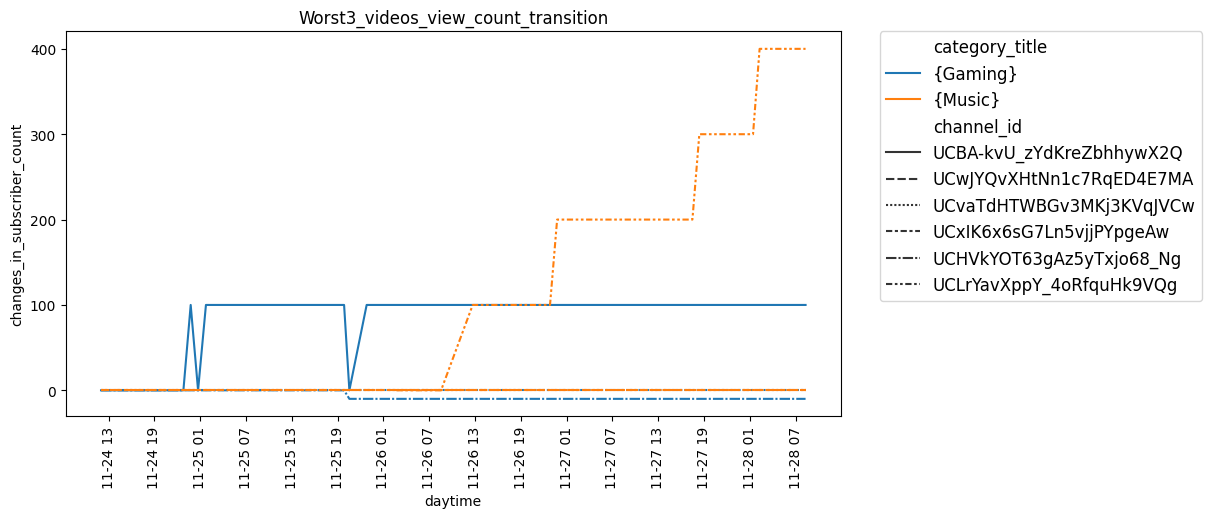

In [153]:
worst_channels_transition = pd.read_sql_query(
    '''
    WITH worst_channels AS(
    SELECT channel_id,category_title,COUNT(channel_id) AS channel_count
    FROM popular_videos
    WHERE category_title IN ('{Music}', '{Gaming}')
    GROUP BY channel_id, category_title
    HAVING COUNT(channel_id)=1),
    worst_music_channels AS(
    SELECT p.daytime, p.video_id, w.channel_id, w.category_title, w.channel_count
    FROM popular_videos p
    INNER JOIN worst_channels w ON p.channel_id=w.channel_id
    WHERE w.category_title='{Music}'
    ORDER BY p.daytime
    LIMIT 3),
    worst_gaming_channels AS(
    SELECT p.daytime, p.video_id, w.channel_id, w.category_title, w.channel_count
    FROM popular_videos p
    INNER JOIN worst_channels w ON p.channel_id=w.channel_id
    WHERE w.category_title='{Gaming}'
    ORDER BY p.daytime
    LIMIT 3),
    selected_channels AS(
    SELECT * FROM worst_music_channels
    UNION ALL
    SELECT * FROM worst_gaming_channels)
    SELECT pc.daytime, pc.channel_id, CAST(pc.subscriber_count AS INTEGER), sc.category_title
    FROM  popular_channels pc
    INNER JOIN selected_channels sc ON pc.channel_id = sc.channel_id
    ORDER BY pc.daytime
    ''',engine)
worst_channels_transition["first_subscriber_count"]= worst_channels_transition.groupby("channel_id")["subscriber_count"].transform("first")
worst_channels_transition["changes_in_subscriber_count"] = worst_channels_transition["subscriber_count"]-worst_channels_transition["first_subscriber_count"]
plt.figure(figsize=(10,5))
sns.lineplot(data=worst_channels_transition, x="daytime", y="changes_in_subscriber_count", hue="category_title", style="channel_id")
plt.title("Worst3_videos_view_count_transition")
plt.xticks(rotation=90)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0, fontsize=12)
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H"))
plt.show()